In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# MNIST Character Recognition

**Handwritten digit recognition** is a computer vision task where a model identifies digits written by humans. It is widely used in applications like bank check processing, postal systems, and OCR (Optical Character Recognition). **In this project**, we build a Convolutional Neural Network (CNN) to recognize digits and deploy it in an interactive interface where users can draw digits and get predictions in real time.

In [1]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


The MNIST dataset contains 70,000 grayscale images of handwritten digits (0–9). Each image is 28×28 pixels. It is a standard benchmark dataset for image classification tasks.

In [2]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

Pixel values are normalized to improve training stability. Images are reshaped to include a channel dimension because CNNs expect 3D input (height, width, channels).

In [3]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**The CNN **extracts features from images using convolution layers. Batch normalization stabilizes training, while pooling reduces image size. Dense layers perform classification. Dropout prevents overfitting.

In [4]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 125s 65ms/step - accuracy: 0.9538 - loss: 0.1619 - val_accuracy: 0.9834 - val_loss: 0.0544
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 117s 52ms/step - accuracy: 0.9806 - loss: 0.0686 - val_accuracy: 0.9896 - val_loss: 0.0342
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 52ms/step - accuracy: 0.9860 - loss: 0.0503 - val_accuracy: 0.9900 - val_loss: 0.0406
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 97s 52ms/step - accuracy: 0.9872 - loss: 0.0462 - val_accuracy: 0.9901 - val_loss: 0.0378
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 97s 52ms/step - accuracy: 0.9904 - loss: 0.0328 - val_accuracy: 0.9899 - val_loss: 0.0414
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 159s 60ms/step - accuracy: 0.9904 - loss: 0.0341 - val_accuracy: 0.9906 - val_loss: 0.0381
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 100s 53ms/step - accuracy: 0.9922 - loss: 0.0289 - val_accuracy: 0.9843 - val_loss: 0.0612
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 52ms/step - accuracy: 0.

The model learns patterns from training data. Accuracy measures correct predictions, while loss shows how well the model fits the data.

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


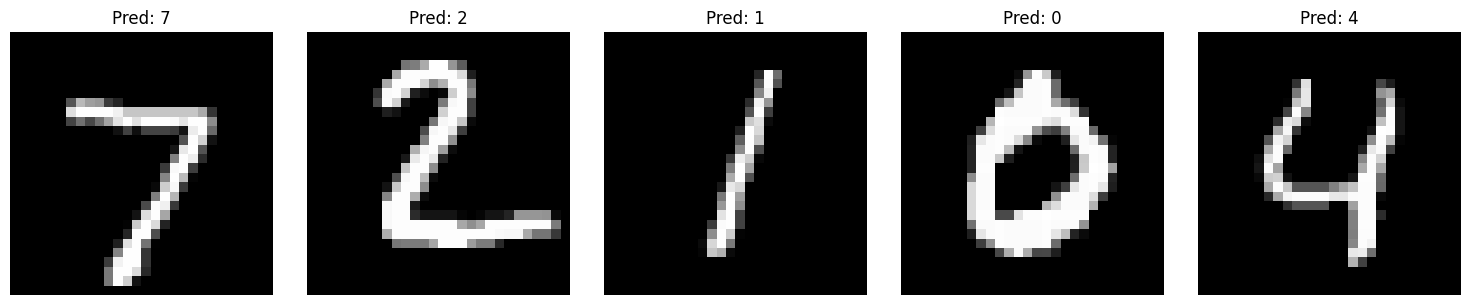

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions
predictions = model.predict(X_test)

# Number of images to display
num_images = 5

# Create a figure with subplots
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))  # 1 row, num_images columns

for i in range(num_images):
    axes[i].imshow(X_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Pred: {np.argmax(predictions[i])}")
    axes[i].axis('off')  # hide axes for clean look

plt.tight_layout()
plt.show()

This plot displays a few handwritten digits from the test set alongside the model’s predicted labels. It allows us to visually verify the CNN’s performance by checking if the predicted digit matches the actual image. Correct predictions indicate that the model has learned to recognize handwritten digits effectively

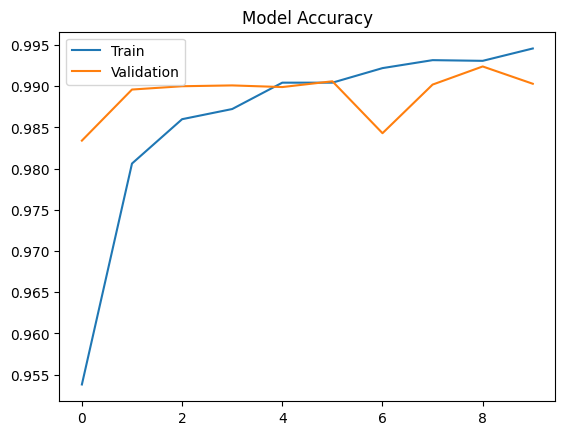

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()

The accuracy plot shows the training and validation accuracy over all epochs. The steady increase and high final values indicate that the model is learning well and generalizing effectively to unseen data. Close training and validation curves suggest minimal overfitting.

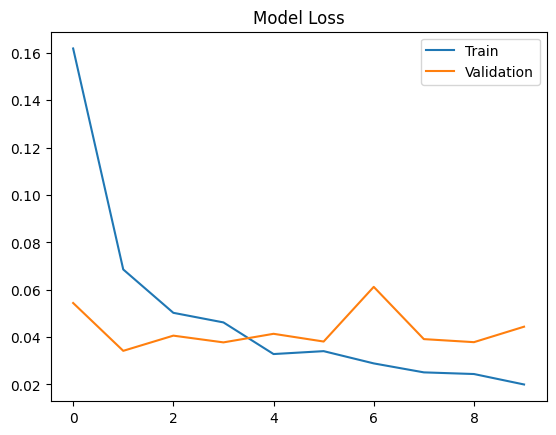

In [7]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])
plt.show()

This plot shows the training and validation loss throughout training. A decreasing loss reflects that the model is reducing its prediction error over time. Small fluctuations in validation loss are normal and indicate minor variations in performance on unseen data.

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


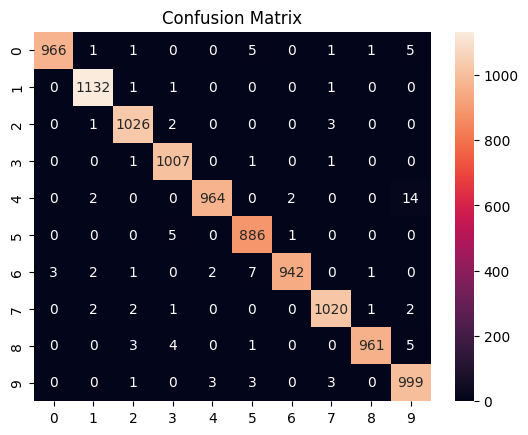

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

cm = confusion_matrix(y_test, pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

The confusion matrix visualizes how the model predicts each digit. Correct predictions appear along the diagonal, while off-diagonal entries show misclassifications. This helps identify which digits are commonly confused by the model, providing insights into potential areas for improvement

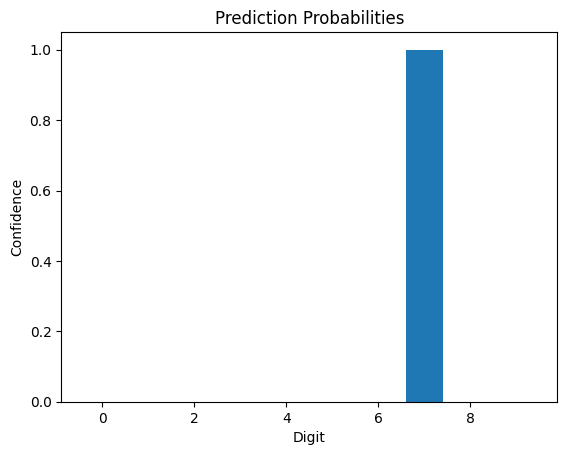

In [9]:
import matplotlib.pyplot as plt

i = 0
plt.bar(range(10), pred[i])
plt.title("Prediction Probabilities")
plt.xlabel("Digit")
plt.ylabel("Confidence")
plt.show()

This chart displays the model's confidence levels for all possible digits from 0 to 9. Only one bar is visible because the model is nearly 100% certain about its prediction, making the probability bars for the other nine digits effectively zero and invisible.

In [27]:
import joblib
model_path = "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition/mnist_model.h5"
model.save(model_path)

In [28]:
!ls "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition"

app.ipynb	      Handwritten_Recognition.ipynb  task3.ipynb
handwritten_model.h5  task3.h5
